# Build Coupled Series with Multivariatizer

`Multivariatizer` wraps a univariate generator and introduces cross-series mixing and lead-lag relationships.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from synforecast import Multivariatizer
from synforecast.generators import TSIGenerator

In [ ]:
base = TSIGenerator(
    min_length=256,
    max_length=256,
    freq="h",
    engine="polars",
    seed=7,
)
coupled = Multivariatizer(base=base, seed=42)
df = coupled.generate(n_series=4)
df.head()

unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,-73.483746
"""0""",2000-01-01 01:00:00,-250.816501
"""0""",2000-01-01 02:00:00,-158.711667
"""0""",2000-01-01 03:00:00,26.946948
"""0""",2000-01-01 04:00:00,-250.057768


The sampled recipe records the transformations, making each generated panel inspectable and reproducible from its seed.

In [ ]:
coupled.last_recipe

{'couplings': ['mixing', 'leadlag'],
 'length': 256,
 'mixing': {'strength': 0.5072149078264366,
  'matrix': array([[ 1.        ,  0.        ,  0.        ,  0.        ],
         [ 0.19725864,  0.98035148,  0.        ,  0.        ],
         [-0.02423582, -0.37406155,  0.92708715,  0.        ],
         [ 0.00973988,  0.45183168, -0.12849622,  0.88274684]])},
 'leadlag': [{'src': 2,
   'dst': 3,
   'lag': 9,
   'sign': -1.0,
   'noise': 0.1807618018379956}]}

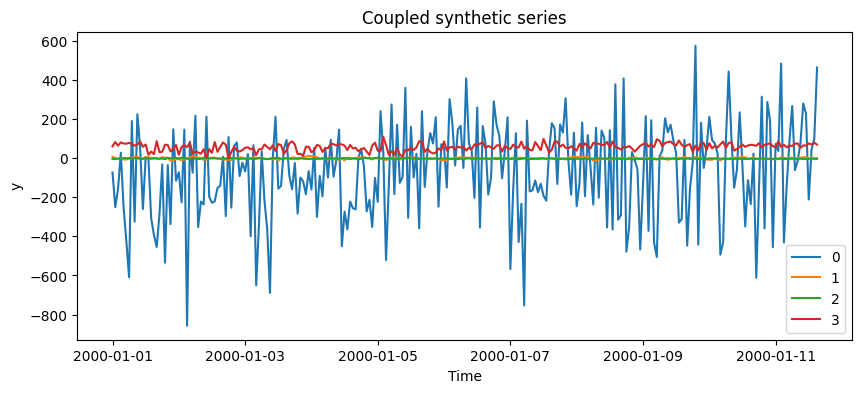

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
for series_id in df["unique_id"].unique().sort().to_list():
    series = df.filter(df["unique_id"] == series_id).sort("ds")
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=series_id)
ax.set(title="Coupled synthetic series", xlabel="Time", ylabel="y")
ax.legend()
plt.show()

In [ ]:
wide = df.pivot(on="unique_id", index="ds", values="y").sort("ds")
np.corrcoef(wide.drop("ds").to_numpy().T)

array([[ 1.        ,  0.13490276, -0.03079865,  0.01106283],
       [ 0.13490276,  1.        , -0.39781199, -0.1085008 ],
       [-0.03079865, -0.39781199,  1.        , -0.15540655],
       [ 0.01106283, -0.1085008 , -0.15540655,  1.        ]])